# Isolation with migration (IM) model på bavian data

I Notebook 03 beregnede jeg det observerede SFS for GOG (*P. anubis*) og Filoha (*P. hamadryas*), og i Notebook 04 arbejdede jeg med tidsinhomogene modeller. Formålet med denne notebook er at tilpasse en Isolation-with-Migration (IM) model til bavian dataene.

IM-modellen er mere realistisk end den simple To-ø model, fordi den eksplicit modellerer, at de to populationer stammer fra en fælles forfaderpopulation, de splittedes ved tidspunktet $T$, og at der siden splittet har været migration med raterne $m_{12}$ og $m_{21}$.

Jeg vil derfor i denne notebook kom ind på følgende:

1. **Datasimulering med msprime** — generer data fra en kendt IM-model
2. **IM-modellens state space** — to-locus ARG med populationsstruktur
3. **Joint probability-graf** — kobling af coalescent og mutationsmodel
4. **Validering** — genfinding af kendte parametre fra simulerede data
5. **Inferens på bavian-data** — SVGD-posterior for GOG og Filoha
6. **Posterior-visualisering**

In [1]:
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, Adamelia, ExpStepSize, ExpRegularization, clear_caches,
    clear_jax_cache, clear_model_cache,
    StateIndexer, Property, PropertySet, set_log_level
) # ALWAYS import phasic first to set jax backend correctly
set_log_level('WARNING')

import numpy as np
import jax.numpy as jnp
import pandas as pd
from typing import Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from tqdm.auto import tqdm
from typing import Optional, Callable
from functools import partial
from itertools import combinations, combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)

from vscodenb import set_vscode_theme
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

## 1. Datasimulering med msprime

Jeg genererer simulerede data fra en kendt IM-model ved hjælp af *msprime*. Dette bruges til validering.

In [2]:
import msprime

def derived_counts(ts, rec_rate):
    records = []
    for var in ts.variants():
        p, g = var.site.position, var.genotypes
        records.append((int(p), p*rec_rate, g.sum()))
    df = pd.DataFrame().from_records(
        records, columns=["pos", "gen_pos", "count"]
        )
    return df

# Sande parametre for simulering 
mut_rate = 5e-10
rec_rate = 1e-8
nr_samples = 5
seq_length = 100_000_000
pop1_size, pop2_size, anc_pop_size = 20_000, 10_000, 15_000
migr_pop1_to_pop2 = 1e-4
migr_pop2_to_pop1 = 5e-4

# Simuler IM-model med msprime
demography = msprime.Demography()
demography.add_population(name="pop1", initial_size=pop1_size)
demography.add_population(name="pop2", initial_size=pop2_size)
demography.set_migration_rate(source="pop1", dest="pop2", rate=migr_pop1_to_pop2)
demography.set_migration_rate(source="pop2", dest="pop1", rate=migr_pop2_to_pop1)
demography.add_population(name="ancestral", initial_size=anc_pop_size)
demography.add_population_split(time=1000, derived=["pop1", "pop2"], ancestral="ancestral")
ts = msprime.sim_ancestry(samples={"pop1": nr_samples, "pop2": 0}, ploidy=1, 
                          demography=demography, recombination_rate=rec_rate, 
                          sequence_length=seq_length, random_seed=12)
ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=5678)
df = derived_counts(ts, rec_rate)
df.to_csv("IM_model_derived_counts.csv", index=False)


In [4]:
def pairs_in_range(nums, diff_lo, diff_hi):
    """
    Find alle SNP-par med fysisk afstand i intervallet [diff_lo, diff_hi].
    Returnerer liste af indeks-par.
    """
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs


df = pd.read_csv("IM_model_derived_counts.csv")

col = "pos" # kan også bruge "gen_pos"
distance, tolerance = 5000, 500
min_dist, max_dist = distance - tolerance, distance + tolerance
records = []
for i, j in pairs_in_range(df[col].values, min_dist, max_dist):
    records.append((df.at[i, col], df.at[j, col], df.at[i, "count"], df.at[j, "count"]))
pairs = pd.DataFrame.from_records(records, columns=["pos1", "pos2", "count1", "count2"])
pairs.head()


,pos1,pos2,count1,count2
0,121835,126784,2,1
1,130693,135293,2,2
2,962978,967549,2,1
3,1645140,1650545,3,4
4,1679198,1684665,1,2


In [5]:
#Fjern overlappende par (par der deler et SNP)
mask = (pairs.pos1 == pairs.pos1.shift()) | (pairs.pos2 == pairs.pos2.shift())
filtered_pairs = pairs.loc[~mask, :]
filtered_pairs.head()

,pos1,pos2,count1,count2
0,121835,126784,2,1
1,130693,135293,2,2
2,962978,967549,2,1
3,1645140,1650545,3,4
4,1679198,1684665,1,2


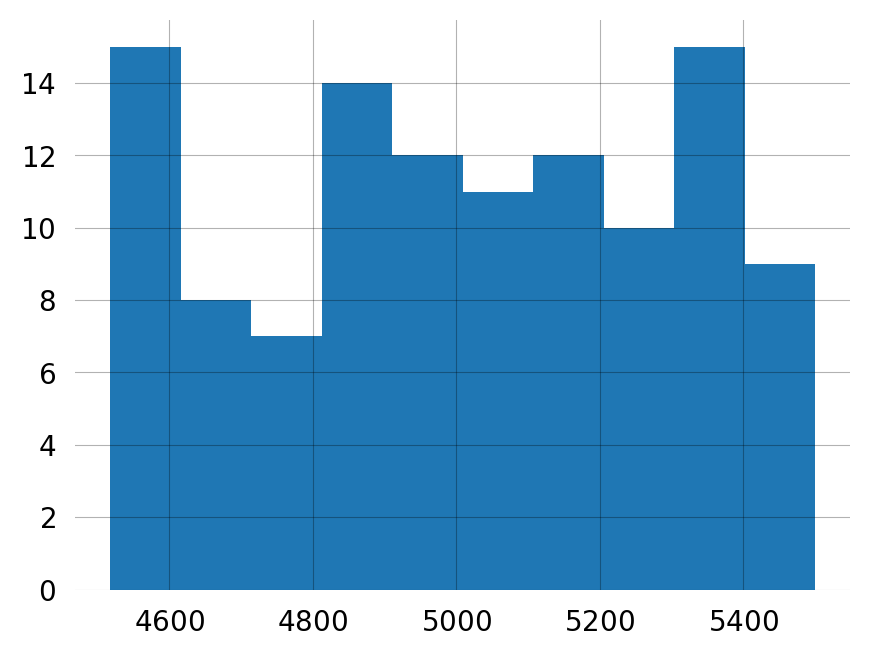

In [20]:
plt.hist(filtered_pairs.pos2 - filtered_pairs.pos1, bins=10) ;

In [6]:
# Konverter til obersvations-matrix
n = len(filtered_pairs)
observations = np.zeros((n, nr_samples), dtype=int)
observations
for i, pair in enumerate(filtered_pairs[["count1", "count2"]].values):
    observations[i, pair] = 1

In [7]:
msg = f"""
Two-locus observations across {nr_samples} samples of {seq_length/1e6:.0f} Mb:
    Mutation rate:
        {mut_rate} events/site/generation
    Recombination rate:
        {rec_rate} crossovers/base/generation
    Haploid population sizes:
        pop1: {pop1_size}
        pop2: {pop2_size}
    Migration rate:
        pop1 -> pop2: {migr_pop1_to_pop2}
        pop2 -> pop1: {migr_pop2_to_pop1}
"""
print(msg)


Two-locus observations across 5 samples of 100 Mb:
    Mutation rate:
        5e-10 events/site/generation
    Recombination rate:
        1e-08 crossovers/base/generation
    Haploid population sizes:
        pop1: 20000
        pop2: 10000
    Migration rate:
        pop1 -> pop2: 0.0001
        pop2 -> pop1: 0.0005



## 2. IM-modellens state space

Jeg bygger nu selve IM-modellen som en to-locus ARG udvidet med populationsstruktur. Modellen er en direkte udvidelse af to-locus ARG-modellen, hvor jeg tilføjer en *in_pop*-egenskab der sporer hvilken population en lineage befinder sig i: 1 = GOG, 2 = Filoha, 3 = ancestral.

Modellen har seks parametre:

| Parameter | Biologisk betydning |
|---|---|
| `theta[0]` | Coalescence-rate i pop1 ($1/N_{e1}$) |
| `theta[1]` | Coalescence-rate i pop2 ($1/N_{e2}$) |
| `theta[2]` | Coalescence-rate i ancestral pop ($1/N_{e,anc}$) |
| `theta[3]` | Rekombinationsrate ($r$) |
| `theta[4]` | Migrationrate $m_{1 \to 2}$ |
| `theta[5]` | Migrationrate $m_{2 \to 1}$ |

In [8]:
indexer = StateIndexer(
    descendants=[
        Property('loc1',   min_value=0, max_value=nr_samples),
        Property('loc2',   min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=3),  # 1=GOG, 2=Filoha, 3=ancestral
    ]
)

# Startstate: nr_samples singletons fra pop1 og pop2, begge med loc1=1, loc2=1
initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(loc1=1, loc2=1, in_pop=1)] = nr_samples
initial[indexer.descendants.props_to_index(loc1=1, loc2=1, in_pop=2)] = nr_samples

print(f"State-rum størrelse: {indexer.state_length}")

State-rum størrelse: 108


In [ ]:
@with_ipv(initial)
def im_model(state, indexer=None):
    """
    Isolation-with-Migration (IM) model — to-locus ARG med populationsstruktur.

    Parametre:
      theta[0] = coalescence-rate i pop1      (1/N_e1)
      theta[1] = coalescence-rate i pop2      (1/N_e2)
      theta[2] = coalescence-rate ancestral   (1/N_e_anc)
      theta[3] = rekombinationsrate           (r)
      theta[4] = migrationrate m_1->2
      theta[5] = migrationrate m_2->1
    """
    transitions = []
    if state.sum() <= 1:
        return transitions

    for i in range(indexer.state_length):
        if state[i] == 0:
            continue
        props_i = indexer.descendants.index_to_props(i)

        # Coalescence 
        for j in range(i, indexer.state_length):
            if state[j] == 0:
                continue
            props_j = indexer.descendants.index_to_props(j)

            # Coalescence kræver begge lineages i samme population
            if props_i.in_pop != props_j.in_pop:
                continue

            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue

            des_loc1 = props_i.loc1 + props_j.loc1
            des_loc2 = props_i.loc2 + props_j.loc2

            if des_loc1 <= nr_samples and des_loc2 <= nr_samples:
                child = state.copy()
                child[i] -= 1
                child[j] -= 1
                child[indexer.descendants.props_to_index(
                    loc1=des_loc1, loc2=des_loc2, in_pop=props_i.in_pop
                )] += 1

                rate = state[i] * (state[j] - same) / (1 + same)
                # [coal_p1, coal_p2, coal_anc, rec, m_12, m_21]
                coeffs = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
                if props_i.in_pop == 1:
                    coeffs[0] = rate
                elif props_i.in_pop == 2:
                    coeffs[1] = rate
                else:
                    coeffs[2] = rate
                transitions.append([child, coeffs])

        # Rekombination (kun lineages der bærer begge loci) 
        if state[i] > 0 and props_i.loc1 > 0 and props_i.loc2 > 0:
            child = state.copy()
            child[i] -= 1
            child[indexer.descendants.props_to_index(
                loc1=0, loc2=props_i.loc2, in_pop=props_i.in_pop
            )] += 1
            child[indexer.descendants.props_to_index(
                loc1=props_i.loc1, loc2=0, in_pop=props_i.in_pop
            )] += 1
            transitions.append([child, [0.0, 0.0, 0.0, float(state[i]), 0.0, 0.0]])

        # Migration (kun mellem pop1 og pop2, ikke til/fra ancestral)
        if state[i] > 0 and props_i.in_pop in (1, 2):
            child = state.copy()
            child[i] -= 1
            if props_i.in_pop == 1:
                child[indexer.descendants.props_to_index(
                    loc1=props_i.loc1, loc2=props_i.loc2, in_pop=2
                )] += 1
                transitions.append([child, [0.0, 0.0, 0.0, 0.0, float(state[i]), 0.0]])
            else:
                child[indexer.descendants.props_to_index(
                    loc1=props_i.loc1, loc2=props_i.loc2, in_pop=1
                )] += 1
                transitions.append([child, [0.0, 0.0, 0.0, 0.0, 0.0, float(state[i])]])

    return transitions

graph = Graph(im_model, indexer=indexer)
print(f"IM-grafen har {graph.vertices_length()} state")
print(f"Antal parametre: {graph.param_length()}")

In [ ]:
graph.plot(nodesep=0.5, wrap=False)

## 3. Joint probability-graf

Fra modelgrafen konstruerer jeg en diskret graf der giver mig mulighed for at beregne joint sandsynligheder for par af SNP-observationer.

In [ ]:
mutation_rate = 1
joint_prob_graph = graph.joint_prob_graph(
    indexer,
    reward_only=['loc1', 'loc2'],
    reward_limit=1,
    tot_reward_limit=2,
    mutation_rate=mutation_rate
)

print(f"Joint probability-graf: {joint_prob_graph.vertices_length()} tilstande")
print(f"Antal parametre (inkl. mutation): {joint_prob_graph.param_length()}")

In [ ]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table.head()

In [ ]:
(1 - joint_prob_table['prob'].sum()).item()

## 4. Validering: genfinding af kendte parametre

Jeg bruger *sample_joint_observations* til at sample testdata fra modellen og tjekker om SVGD kan genfinde de sande parametre.

In [ ]:
def sample_joint_observations(joint_prob_graph, theta, nr_observations=1000):
    joint_prob_graph.update_weights(theta)
    joint_prob_table = joint_prob_graph.joint_prob_table()
    p = joint_prob_table['prob'] / joint_prob_table['prob'].sum()
    p = p.to_numpy()
    sample = np.random.choice(joint_prob_table.index.values, nr_observations, p=p)
    observations = joint_prob_table.loc[sample, joint_prob_table.columns[:-1]].to_numpy().tolist()
    return observations

# Sande parametre: [coal_p1, coal_p2, coal_anc, rec, m_12, m_21, mutation_rate]
true_theta = [10, 20, 13, 1, 2, 5, mutation_rate]

observations_val = sample_joint_observations(joint_prob_graph, true_theta, nr_observations=1000)
observations_val[:5]

In [ ]:
# Filtrer til kun observationer mulige under modellen
modelled_obs = joint_prob_graph.joint_prob_table()
allowed_observations = set(tuple(x) for x in modelled_obs[modelled_obs.columns[:-1]].to_numpy().tolist())
observations_val = [o for o in observations_val if tuple(o) in allowed_observations]
observations_val = np.array(observations_val)
observations_val

In [ ]:
ExpStepSize(first_step=0.1, last_step=0.01, tau=50.0).plot(100);

In [ ]:
svgd_val = joint_prob_graph.svgd(
    observed_data=observations_val,
    fixed=[(6, mutation_rate)],
    n_iterations=100,
    n_particles=200,
    prior=[
        GaussPrior(ci=[5, 25]),   # coal pop1
        GaussPrior(ci=[5, 25]),   # coal pop2
        GaussPrior(ci=[5, 25]),   # coal ancestral
        GaussPrior(ci=[0, 3]),    # rekombination
        GaussPrior(ci=[0, 3]),    # m_12
        GaussPrior(ci=[0, 3]),    # m_21
        None
    ],
    learning_rate=ExpStepSize(first_step=0.1, last_step=0.01, tau=50.0),
)
svgd_val.summary()

In [ ]:
svgd_val.plot_ci(ci_method='hpd')

In [ ]:
svgd_val.plot_convergence();

In [ ]:
svgd_val.plot_trace()

In [ ]:
svgd_val.map_estimate_from_particles()

In [ ]:
svgd_val.plot_hdr()

In [ ]:
svgd_val.plot_pairwise(true_theta=true_theta);

## 5. Inferens på bavian data

Jeg ser nu på bavian data fra kromosom 20.

In [2]:
import sgkit as sg

# Indlæs datasættet
ds = sg.load_dataset("/faststorage/project/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021_ZARR/chr20.phased.rehead.vcz")

# Populationsdefinitioner (fra Notebook 03)
gog_samples = [
    'PD_0720', 'PD_0721', 'PD_0722', 'PD_0723', 'PD_0724', 'PD_0725', 'PD_0726',
    'PD_0727', 'PD_0728', 'PD_0729', 'PD_0730', 'PD_0731', 'PD_0732', 'PD_0733',
    'PD_0734', 'PD_0735', 'PD_0736', 'PD_0737', 'PD_0738', 'PD_0739', 'PD_0740',
    'PD_0741', 'PD_0742', 'PD_0743', 'PD_0744'
]
filoha_samples = [
    'PD_0696', 'PD_0697', 'PD_0698', 'PD_0699', 'PD_0700', 'PD_0701', 'PD_0702',
    'PD_0703', 'PD_0704', 'PD_0705', 'PD_0706', 'PD_0707', 'PD_0708', 'PD_0709',
    'PD_0710', 'PD_0711', 'PD_0712', 'PD_0713', 'PD_0714', 'PD_0715', 'PD_0716',
    'PD_0717', 'PD_0718', 'PD_0719'
]

# Subset til datasættet
mask_gog    = ds["sample_id"].isin(gog_samples).values
mask_filoha = ds["sample_id"].isin(filoha_samples).values
ds_gog    = ds.isel(samples=mask_gog)
ds_filoha = ds.isel(samples=mask_filoha)

print(f"GOG:    {ds_gog.dims['samples']} individer")
print(f"Filoha: {ds_filoha.dims['samples']} individer")


GOG:    25 individer
Filoha: 24 individer


/tmp/ipykernel_3573605/4174446639.py:26: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"GOG:    {ds_gog.dims['samples']} individer")
/tmp/ipykernel_3573605/4174446639.py:27: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Filoha: {ds_filoha.dims['samples']} individer")


In [3]:
# Beregn derived allele counts
def compute_derived_counts(ds_sub):
    """Beregn derived allele counts per variant (fra Notebook 03)."""
    vac = sg.count_variant_alleles(ds_sub)
    ac  = vac["variant_allele_count"].values
    total = ac.sum(axis=1)
    df = pd.DataFrame({
        "pos":   ds_sub["variant_position"].values,
        "count": ac[:, 1],
    })
    return df[(ac[:, 1] > 0) & (ac[:, 1] < total)].reset_index(drop=True)

df_gog    = compute_derived_counts(ds_gog)
df_filoha = compute_derived_counts(ds_filoha)

print(f"GOG:    {len(df_gog):,} segregerende varianter")
print(f"Filoha: {len(df_filoha):,} segregerende varianter")

GOG:    528,250 segregerende varianter
Filoha: 460,025 segregerende varianter


In [ ]:
# Find SNP-par for hvert population og merge på fælles positioner
def get_filtered_pairs(df):
    records = []
    for i, j in pairs_in_range(df["pos"].values, min_dist, max_dist):
        records.append((df.at[i, "pos"], df.at[j, "pos"],
                        df.at[i, "count"], df.at[j, "count"]))
    pairs = pd.DataFrame.from_records(records, columns=["pos1", "pos2", "count1", "count2"])
    mask = (pairs.pos1 == pairs.pos1.shift()) | (pairs.pos2 == pairs.pos2.shift())
    return pairs.loc[~mask, :].reset_index(drop=True)

pairs_gog    = get_filtered_pairs(df_gog)
pairs_filoha = get_filtered_pairs(df_filoha)

# Merge: kun par der er til stede i begge populationer
merged = pairs_gog.merge(
    pairs_filoha, on=["pos1", "pos2"], suffixes=("_gog", "_filoha")
)

print(f"GOG SNP-par:                    {len(pairs_gog):,}")
print(f"Filoha SNP-par:                 {len(pairs_filoha):,}")
print(f"Matchede SNP-par (fælles pos):  {len(merged):,}")
merged.head()

In [ ]:
plt.hist(merged.pos2 - merged.pos1, bins=10);

In [ ]:
# Konverter til observations-matrix
n = len(merged)
n_samples_baboon = ds_gog.dims['samples']
observations_baboon = np.zeros((n, n_samples_baboon), dtype=int)
for i, pair in enumerate(merged[["count1_gog", "count1_filoha"]].values):
    observations_baboon[i, pair] = 1

# Filtrer til kun observationer mulige under modellen
modelled_obs = joint_prob_graph.joint_prob_table()
allowed_observations = set(tuple(x) for x in modelled_obs[modelled_obs.columns[:-1]].to_numpy().tolist())
observations_baboon = [o for o in observations_baboon.tolist() if tuple(o) in allowed_observations]
observations_baboon = np.array(observations_baboon)
observations_baboon

In [ ]:
svgd_baboon = joint_prob_graph.svgd(
    observed_data=observations_baboon,
    fixed=[(6, mutation_rate)],
    n_iterations=100,
    n_particles=200,
    prior=[
        GaussPrior(ci=[5, 50]),   # coal pop1 (GOG)
        GaussPrior(ci=[5, 50]),   # coal pop2 (Filoha)
        GaussPrior(ci=[5, 50]),   # coal ancestral
        GaussPrior(ci=[0, 3]),    # rekombination
        GaussPrior(ci=[0, 3]),    # m_12
        GaussPrior(ci=[0, 3]),    # m_21
        None
    ],
    learning_rate=ExpStepSize(first_step=0.1, last_step=0.01, tau=50.0),
)

print("SVGD Resultat — IM-model på bavian-data")
svgd_baboon.summary()

In [ ]:
svgd_baboon.plot_ci(ci_method='hpd')

In [ ]:
svgd_baboon.plot_convergence();

In [ ]:
svgd_baboon.plot_trace()

In [ ]:
svgd_baboon.map_estimate_from_particles()

In [ ]:
svgd_baboon.plot_hdr()

In [ ]:
svgd_baboon.plot_pairwise();

In [ ]:
svgd_baboon.animate_pairwise()

## Opsummering

| Trin | Resultat |
|---|---|
| msprime-simulering | IM-demografi med split, migration og ancestral pop |
| State space | To-locus ARG med `in_pop ∈ {1, 2, 3}` og 6 parametre |
| Joint probability-graf | `reward_only=['loc1','loc2']`, `tot_reward_limit=2` |
| Validering | SVGD på simulerede data — genfinding af kendte parametre |
| Inferens | SVGD-posterior for GOG vs. Filoha på chr20-data |

I Notebook 06 tester jeg Two-island modellen på de samme data. Two-island modellen har ingen ancestral population og ingen eksplicit split-tidspunkt, der er tale om to populationer der altid har eksisteret adskilt med konstant migration.